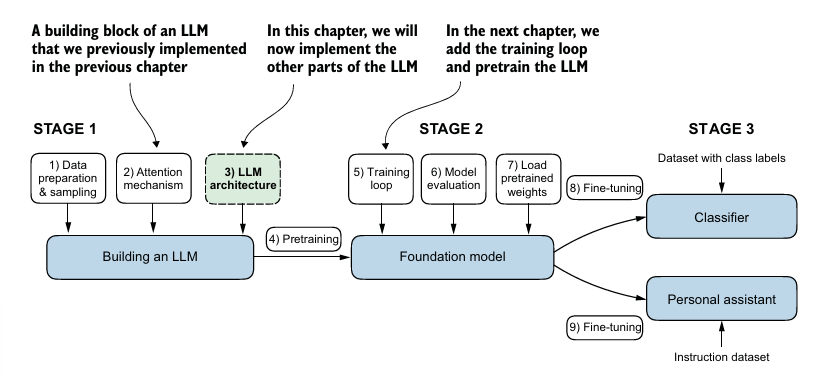

In [1]:
# Configuration of the small GPT-2 model 

GPT_CONFIG_124M = {
    "vocab_size":50257,        # Vocabulary size
    "context_length":1024,     # Context length
    "emb_dim":768,             # Embedding dimension
    "n_heads":12,              # Number of attention heads
    "n_layers":12,             # Number of layers
    "drop_rate":0.1,           # Dropout rate
    "qkv_bias":False           # Query-Key-Value bias
}

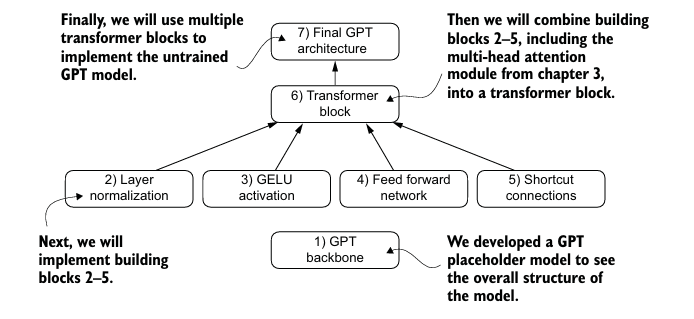

In [2]:
#  A placeholder GPT model architecture class

import torch 
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg['context_length'], cfg['emb_dim'])
        self.drop_emb = nn.Dropout(cfg['drop_rate'])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg)
              for _ in range(cfg["n_layers"])]
        )

        self.final_norm = DummLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg['vocab_size'], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))

        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits
    
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):
        return x 
    
class DummLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        return x 

In [3]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))

batch = torch.stack(batch, dim=0)
print(batch.shape)
print(batch)

torch.Size([2, 4])
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [4]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


#### Normalizing activations with layer normalization

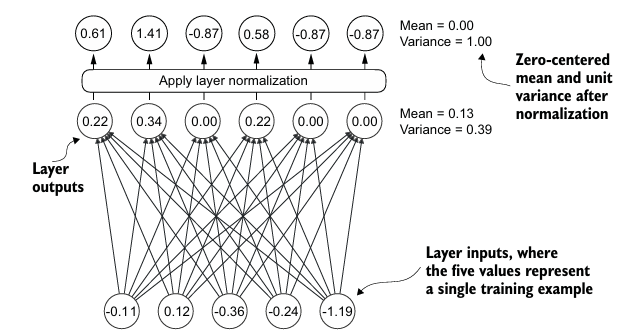

In [5]:
torch.manual_seed(123)
batch_example = torch.randn(2,5)
layer = nn.Sequential(nn.Linear(5,6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [6]:
# Before apply layer nomalization the mean and variance:

mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("Mean: \n", mean)
print("Variance: \n", var)

Mean: 
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance: 
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [7]:
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [8]:
# Layer Normalization Class 

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


In [9]:
torch.set_printoptions(sci_mode=False)

ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


#### Implementing a feed forward network with GELU activations

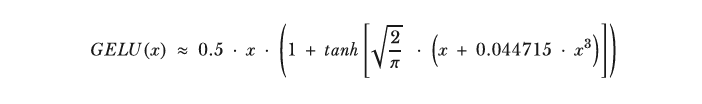

In [10]:
# An implementation of the GELU activation function

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return  0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0/torch.pi)) *
            (x + 0.447515 * torch.pow(x,3))
        ))
    
    

In [11]:
#  A feed forward neural network module

class FeedForward(nn.Module):

    def __init__(self,cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg['emb_dim'], 4* cfg["emb_dim"]),
            GELU(),
            nn.Linear(4* cfg["emb_dim"],  cfg["emb_dim"])
        )

    def forward(self, x):
        return self.layers(x)

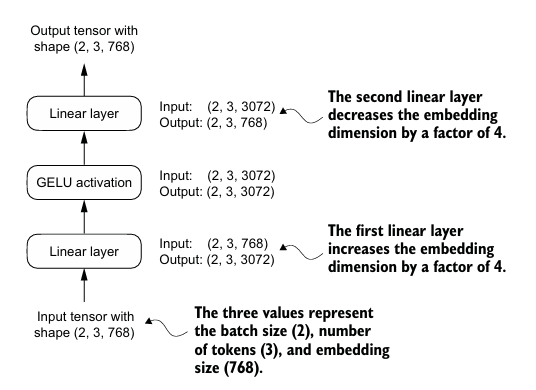

In [12]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)         
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


#### Adding shortcut connections

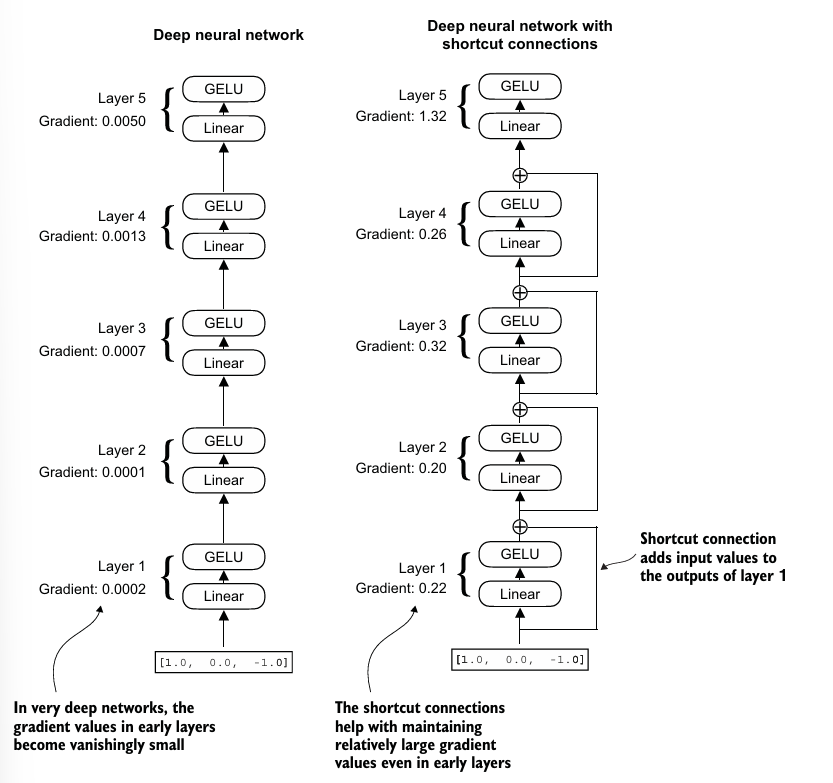

In [13]:
# A neural network to illustrate shortcut connections

class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]),
                          GELU()),
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output

        return x 

In [14]:
layer_sizes = [3, 3, 3, 3, 3, 1]  
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)                           
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)

In [15]:
def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([0.])

    loss = nn.MSELoss()
    loss = loss(output, target)

    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [16]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020471613970585167
layers.1.0.weight has gradient mean of 0.00012318225344642997
layers.2.0.weight has gradient mean of 0.0007344917394220829
layers.3.0.weight has gradient mean of 0.0013871104456484318
layers.4.0.weight has gradient mean of 0.005026474129408598


c:\Users\lokes\miniconda3\envs\nanogpt\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [17]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.29923516511917114
layers.1.0.weight has gradient mean of 0.27497780323028564
layers.2.0.weight has gradient mean of 0.45471858978271484
layers.3.0.weight has gradient mean of 0.36301329731941223
layers.4.0.weight has gradient mean of 1.763328194618225


####  Connecting attention and linear layers in a transformer block

In [18]:
import os 
os.chdir("../")

In [19]:
print(os.getcwd())

d:\lokesh\DS\LLM_from-scratch


In [20]:
# The transformer block component of GPT 

from coding_attention_mechanisms_2.attention_mechanism import MultiHeadAttention

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in = cfg["emb_dim"],
            d_out = cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )

        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):

        shortcut = x
        x = self.norm1(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x 
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x 

In [21]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768)                  
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)
print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


In [22]:
#  The GPT model architecture implementation

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len  = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)

        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )

        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [23]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.0469,  0.4268,  0.1252,  ...,  0.4189, -0.2553, -0.1266],
         [ 0.4785, -0.4133, -0.4624,  ..., -0.1931,  0.1493,  0.1166],
         [ 0.6383, -0.0173, -0.6335,  ...,  0.6659, -1.0930, -0.1711],
         [-0.7828,  0.4417, -0.3711,  ...,  0.9702,  0.1009, -0.4042]],

        [[-0.0751, -0.0564,  0.6274,  ...,  0.3827, -0.1784, -0.3694],
         [ 0.0569,  0.1275, -0.0422,  ...,  0.6600, -0.2572,  0.7278],
         [ 1.2574,  0.6300, -0.4351,  ...,  0.7098, -0.0615, -0.2377],
         [ 0.4577,  0.1173,  0.6022,  ...,  1.4067, -0.7204, -0.0662]]],
       grad_fn=<UnsafeViewBackward0>)


In [24]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


In [25]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [28]:
total_params_gpt2 = (
    total_params - sum(p.numel()
    for p in model.out_head.parameters())
)
print(f"Number of trainable parameters "
      f"considering weight tying: {total_params_gpt2:,}"
)

Number of trainable parameters considering weight tying: 124,412,160


#### Exercise 4.1 Number of parameters in feed forward and attention modules 
Calculate and compare the number of parameters that are contained in the feed forward module and those that are contained in the multi-head attention module.

In [44]:
total_params_ff = sum(p.numel()
    for p in model.trf_blocks[0].ff.parameters() )

total_params_att = sum(p.numel()
    for p in model.trf_blocks[0].att.parameters() )

print("Number of parameters in FeedForward Neural Network: ", total_params_ff)
print("Number of parameters in Multi Head Attention: ", total_params_att)

Number of parameters in FeedForward Neural Network:  4722432
Number of parameters in Multi Head Attention:  2360064


In [46]:
#  let’s compute the memory requirements of the 163 million parameters

total_size_bytes = total_params * 4 
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


#### Exercise 4.2 Initializing larger GPT models 
We initialized a 124-million-parameter GPT model, which is known as "GPT-2 small." Without making any code modifications besides updating the configuration file, use the GPTModel class to implement GPT-2 medium (using 1,024-dimensional embeddings, 24 transformer blocks, 16 multi-head attention heads), GPT-2 large (1,280 dimensional embeddings, 36 transformer blocks, 20 multi-head attention heads),
and GPT-2 XL (1,600-dimensional embeddings, 48 transformer blocks, 25 multi-head attention heads). As a bonus, calculate the total number of parameters in each GPT model.

In [47]:
# Configuration of the small GPT-2 model 

GPT_CONFIG_124M = {
    "vocab_size":50257,        # Vocabulary size
    "context_length":1024,     # Context length
    "emb_dim":768,             # Embedding dimension
    "n_heads":12,              # Number of attention heads
    "n_layers":12,             # Number of layers
    "drop_rate":0.1,           # Dropout rate
    "qkv_bias":False           # Query-Key-Value bias
}

# Configuration of the small GPT-2 Medium
GPT_CONFIG_MEDIUM = {
    "vocab_size":50257,        # Vocabulary size
    "context_length":1024,     # Context length
    "emb_dim":1024,             # Embedding dimension
    "n_heads":16,              # Number of attention heads
    "n_layers":24,             # Number of layers
    "drop_rate":0.1,           # Dropout rate
    "qkv_bias":False           # Query-Key-Value bias
}

# Configuration of the small GPT-2 Large
GPT_CONFIG_LARGE = {
    "vocab_size":50257,        # Vocabulary size
    "context_length":1024,     # Context length
    "emb_dim":1280,             # Embedding dimension
    "n_heads":20,              # Number of attention heads
    "n_layers":36,             # Number of layers
    "drop_rate":0.1,           # Dropout rate
    "qkv_bias":False           # Query-Key-Value bias
}

# Configuration of the small GPT-2XL
GPT_CONFIG_XL = {
    "vocab_size":50257,        # Vocabulary size
    "context_length":1024,     # Context length
    "emb_dim":1600,             # Embedding dimension
    "n_heads":25,              # Number of attention heads
    "n_layers":48,             # Number of layers
    "drop_rate":0.1,           # Dropout rate
    "qkv_bias":False           # Query-Key-Value bias
}

In [48]:
torch.manual_seed(123)
medium_model = GPTModel(GPT_CONFIG_MEDIUM)
out = medium_model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.6072,  0.4844,  0.7080,  ..., -0.1437,  0.1122,  0.8953],
         [-0.3826,  0.0695, -0.4054,  ..., -0.4530,  0.0904, -0.8136],
         [-0.3305,  0.3654, -0.2893,  ...,  0.3663,  0.2110,  0.5351],
         [-0.3252,  1.0106, -1.1885,  ...,  0.3140,  0.0552, -0.2439]],

        [[-0.3572,  0.0914,  0.4277,  ...,  0.3971,  0.4972,  0.8458],
         [-0.7015, -0.4004, -0.4659,  ..., -0.5365,  0.6675, -0.5042],
         [-0.4400,  0.0422, -0.8780,  ..., -0.4172,  0.4638,  0.6152],
         [-0.0159,  1.2897, -0.6673,  ..., -0.2898, -0.4862,  0.1184]]],
       grad_fn=<UnsafeViewBackward0>)


In [61]:
total_params_medium_model = sum(p.numel() for p in medium_model.parameters())
print(f"Total number of parameters in medium size GPT Model : ",total_params_medium_model)

total_size_bytes = total_params_medium_model * 4      
total_size_mb = total_size_bytes / (1024 * 1024 * 1024)    
print(f"Total size of the medium model: {total_size_mb:.2f} GB")

Total number of parameters in medium size GPT Model :  406212608
Total size of the medium model: 1.51 GB


In [60]:
large_model = GPTModel(GPT_CONFIG_LARGE)

total_params_large_model = sum(p.numel() for p in large_model.parameters())
print(f"Total number of parameters in Large size GPT Model : ",total_params_large_model)

total_size_bytes = total_params_large_model * 4      
total_size_mb = total_size_bytes / (1024 * 1024 * 1024)    
print(f"Total size of the large model: {total_size_mb:.2f} GB")

Total number of parameters in Large size GPT Model :  838220800
Total size of the large model: 3.12 GB


In [57]:
xl_model = GPTModel(GPT_CONFIG_XL)

total_params_xl_model = sum(p.numel() for p in xl_model.parameters())
print(f"Total number of parameters in xl size GPT Model : ",total_params_xl_model)

total_size_bytes = total_params_xl_model * 4      
total_size_mb = total_size_bytes / (1024 * 1024 * 1024)    
print(f"Total size of the xl model: {total_size_mb:.2f} GB")

Total number of parameters in xl size GPT Model :  1637792000
Total size of the xl model: 6.10 GB


#### Generating text

We will now implement the code that converts the tensor outputs of the GPT model back into text.

In [62]:
# function for the GPT model to generate text

def generate_text_simple(model, idx, 
                         max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:,-1,:]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=-1)

    return idx 

In [68]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)   # <- adds batch dimension
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [70]:
model.eval()
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Outpu: ", out)
print("Output length: ", len(out[0]))

Outpu:  tensor([[15496,    11,   314,   716, 23307, 15414,  3443, 32202, 33205,  7415]])
Output length:  10


tensor([[15496,    11,   314,   716, 23307, 15414,  3443, 32202, 33205,  7415]])

In [74]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I amTooinput finally crab Jehovah yesterday
